# From Phone Photo to Top-Down Floor Plan

In production systems, floor plans are rarely provided as perfectly scanned
documents.

Users usually take photographs using a mobile phone.

These images contain:

- perspective distortion
- rotation
- shadows
- reflections
- screen glare
- blur
- camera noise

Before any segmentation model is applied, the image should be geometrically
normalized.

This notebook demonstrates that preprocessing pipeline using OpenCV.

In [114]:
import sys
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(str(Path.cwd().parent))

from src.visualization import show_images
from src.io_utils import load_image, save_image

## The Input Problem (why use perspective correction)

When a floor plan is photographed using a mobile phone, the camera is rarely
perfectly parallel to the document.

As a result, the rectangular floor plan undergoes a projective transformation,
causing perspective distortion and instead of appearing as a rectangle, the document becomes a trapezoid.

Perspective distortion introduces several problems for downstream computer
vision algorithms:

- wall lengths become inconsistent
- wall thickness varies across the image
- right angles are no longer preserved
- room proportions become distorted
- measurements are unreliable

Since floor plans are planar objects, these distortions can be corrected using
a homography transformation before segmentation.

In [115]:
reference_rgb = load_image("../data/floor_plan_original.jpg")
phone_rgb = load_image("../data/floor_plan_photo.jpg")

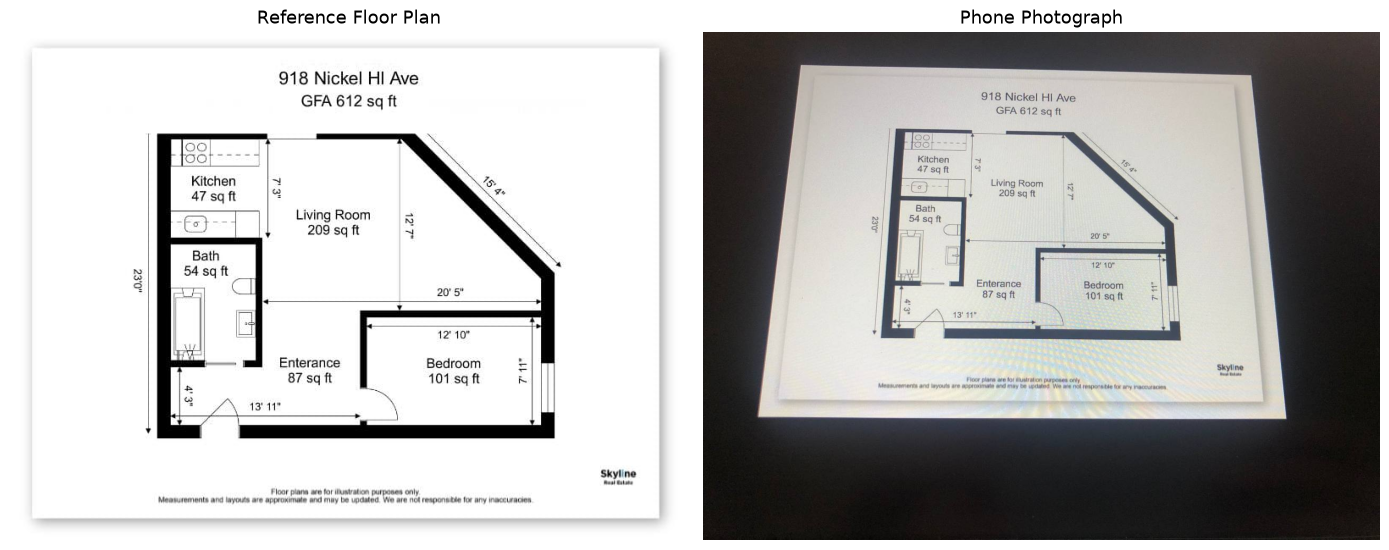

In [116]:
show_images(
    [reference_rgb, phone_rgb],
    ["Reference Floor Plan", "Phone Photograph"],
    nrows=1, ncols=2
)

In [118]:
print("Reference image")
print("----------------")
print(f"Shape: {reference_rgb.shape}")
print(f"Data type: {reference_rgb.dtype}")

print()

print("Phone photo")
print("----------------")
print(f"Shape: {phone_rgb.shape}")
print(f"Data type: {phone_rgb.dtype}")

Reference image
----------------
Shape: (600, 800, 3)
Data type: uint8

Phone photo
----------------
Shape: (960, 1280, 3)
Data type: uint8


The phone image usually has a higher resolution than the original floor plan, which is common in real-world scenarios.
 
The image could be resized to reduce computational cost while preserving enough detail for geometric processing.

## Detecting the Document


Before estimating a homography, the document must be located within the image.

Since the floor plan occupies most of the photograph, we can detect its outer
boundary using classical computer vision techniques.

The pipeline consists of:

**Phone Image**

↓

**Grayscale Conversion**

↓

**Gaussian Blur**

↓

**Canny Edge Detection**

↓

**Contour Detection**

↓

**Largest Contour**


The largest contour is assumed to correspond to the floor plan boundary.

### Grayscale

In [120]:
reference_gray = cv2.cvtColor(reference_rgb, cv2.COLOR_RGB2GRAY)
phone_gray = cv2.cvtColor(phone_rgb, cv2.COLOR_RGB2GRAY)

### Gaussian Blur

Noise causes Canny to produce many false edges. The image needs to be smoothed first.

In [121]:
blur = cv2.GaussianBlur(
    phone_gray,
    (5,5),
    sigmaX=0
)

### Canny

The Canny algorithm is a multi-step pipeline that includes :

- **Intensity Gradient Calculation**: Uses a Sobel kernel to find the horizontal $G_{x}$ and vertical $G_{y}$ derivatives to calculate gradient magnitude and direction.

- **Non-Maximum Suppression**: Suppresses all pixels that are not local maxima along the gradient direction, thinning thick edges.

- **Hysteresis Thresholding**: Cleans up weak edges using two threshold values to decide which edge pixels to keep, link, or discard.

In [122]:
LOW_THRESHOLD = 50     # The lower bound for the hysteresis thresholding step
HIGH_THRESHOLD = 150   # The upper bound for the hysteresis thresholding step

edges = cv2.Canny(
    blur,
    LOW_THRESHOLD,
    HIGH_THRESHOLD
)

### Find contours

**cv2.findContours** extracts geometric boundaries from the binary edge image. 
  - `RETR_EXTERNAL`: Retrieves only the outermost boundaries, ignoring internal floor plan details like furniture or walls.

  - `CHAIN_APPROX_SIMPLE`: Compresses horizontal, vertical, and diagonal segments into their end points to save memory.


In [123]:
contours, hierarchy = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

### Largest contour

**max(contours, key=cv2.contourArea)** evaluates the area of every detected contour and extracts the single largest one, which represents the outer boundary of the floor plan document page.

In [124]:
largest_contour = max(
    contours,
    key=cv2.contourArea
)

### Draw contour

In [125]:
contour_image = phone_rgb.copy()

cv2.drawContours(
    contour_image,
    [largest_contour],
    -1,
    (255,0,0),
    6
);

### Visualization

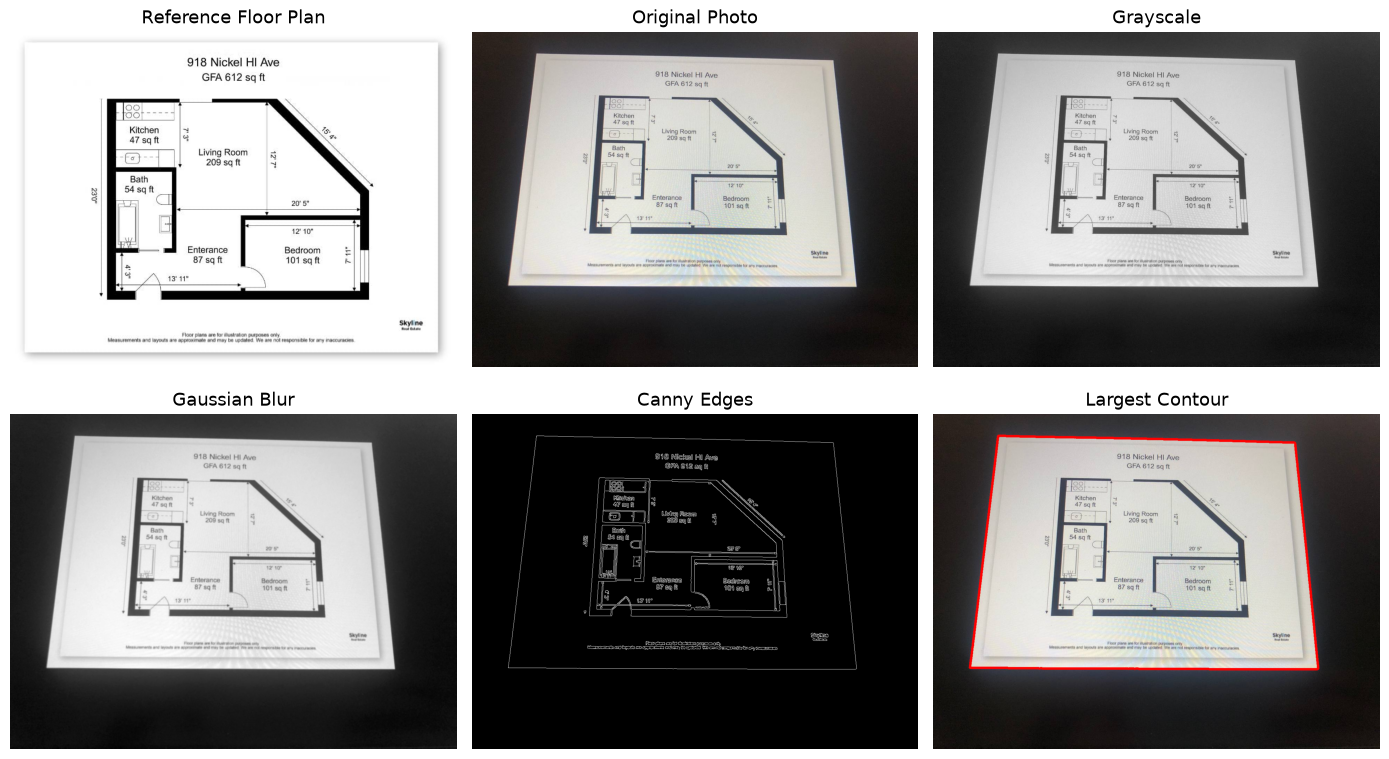

In [126]:
show_images(
    [reference_rgb,
     phone_rgb, 
     phone_gray, 
     blur, 
     edges,
     contour_image
     ],
    ["Reference Floor Plan",
     "Original Photo", 
     "Grayscale", 
     "Gaussian Blur",
     "Canny Edges", 
     "Largest Contour"
     ],
    nrows=2, ncols=3
)

In [127]:
print(f"Number of contours detected : {len(contours)}")

print(f"Original contour points : {len(largest_contour)}")

print(f"Largest contour area : {cv2.contourArea(largest_contour):,.0f} pixels")

image_area = phone_gray.shape[0] * phone_gray.shape[1]

print(f"Image area : {image_area:,} pixels")

print(f"Coverage : {100*cv2.contourArea(largest_contour)/image_area:.2f}%")

Number of contours detected : 1
Original contour points : 366
Largest contour area : 609,071 pixels
Image area : 1,228,800 pixels
Coverage : 49.57%


The largest contour covers approximately 50% of the image, supporting the assumption that it corresponds to the photographed floor plan. In controlled document-scanning scenarios, selecting the largest external contour is a simple and effective heuristic. However, in cluttered scenes or when the document is partially occluded, more robust approaches such as deep-learning-based document detectors or segmentation models may be required.

## Polygon Approximation

The contour extracted from the edge image typically contains hundreds or even
thousands of points.

For homography estimation, however, only at least four document corners are needed.

OpenCV provides the Douglas–Peucker polygon simplification algorithm through
`cv2.approxPolyDP()`. The algorithm approximates a contour using fewer vertices
while preserving its overall shape.

- `cv2.arcLength`: Calculates the total perimeter of the largest contour

- `epsilon`: Defines the approximation accuracy tolerance (set here to 2% of the total contour perimeter). Larger values simplify the contour more aggressively, while smaller values preserve more detail.

- `cv2.approxPolyDP`: Applies the Douglas-Peucker algorithm to output a simplified polygon containing only the dominant vertices

In [128]:
# Approximation accuracy
epsilon = 0.02 * cv2.arcLength(largest_contour, closed=True)

print(f"Douglas-Peucker epsilon: {epsilon:.2f}")

approx_polygon = cv2.approxPolyDP(
    largest_contour,
    epsilon,
    closed=True
)

print(f"Approximated vertices : {len(approx_polygon)}")

Douglas-Peucker epsilon: 64.72
Approximated vertices : 4


In [129]:
polygon_vis = phone_rgb.copy()

# Draw approximated polygon (green)
cv2.polylines(
    polygon_vis,
    [approx_polygon],
    True,
    (0, 255, 0),
    5
)

# Draw corner points
for i, point in enumerate(approx_polygon):

    x, y = point[0]

    cv2.circle(
        polygon_vis,
        (x, y),
        10,
        (255, 255, 0),
        -1
    )

    cv2.putText(
        polygon_vis,
        str(i),
        (x + 15, y - 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,255,255),
        2
    )

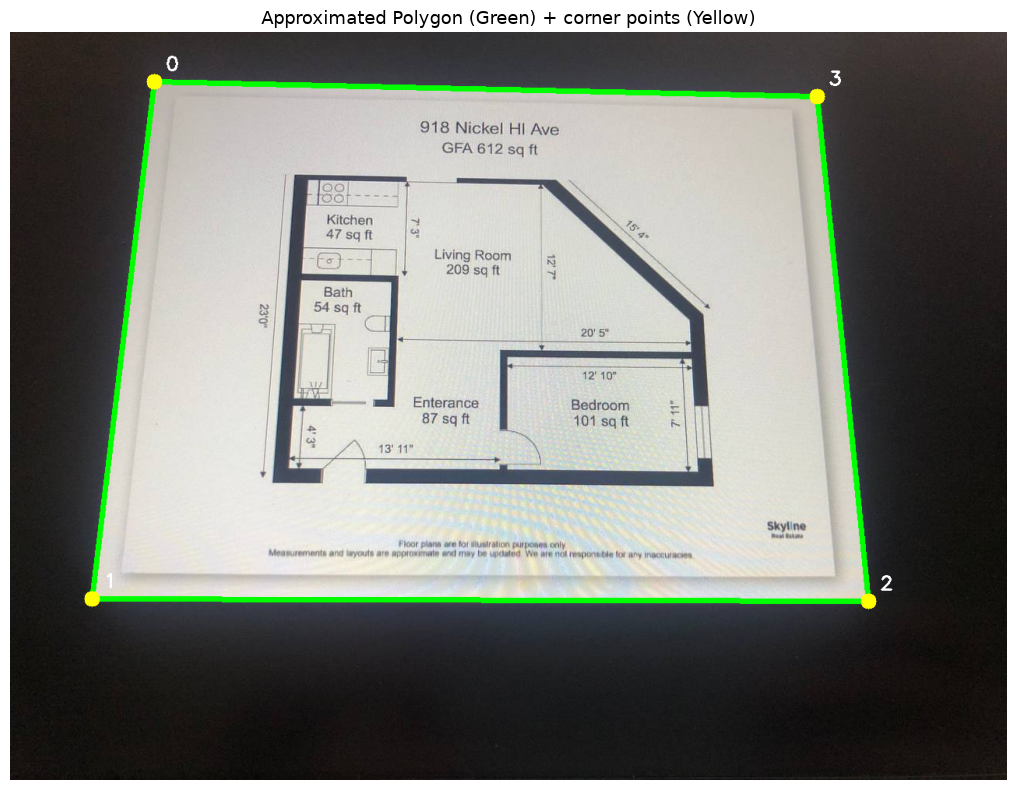

In [130]:
show_images(
    [polygon_vis],
    ["Approximated Polygon (Green) + corner points (Yellow)"],
    nrows=1, ncols=1
)

## Ordering the Corners

Although the approximated polygon contains the correct four vertices, OpenCV
does not guarantee any particular ordering.

For perspective correction, the source and destination points must correspond
to one another.

The vertices are therefore reordered into a consistent clockwise order:

1. Top-left
2. Top-right
3. Bottom-right
4. Bottom-left

Without this ordering, the homography may rotate, mirror, or severely distort
the floor plan.

In [131]:
if len(approx_polygon) != 4:
    raise ValueError(
        f"Expected 4 corner points, but found {len(approx_polygon)}. "
        "Try adjusting the approximation tolerance (epsilon) or improve the document detection step."
    )

# Extract points
corners = approx_polygon.reshape(4, 2)

print(corners)

[[ 185   63]
 [ 105  727]
 [1102  730]
 [1036   82]]


In [132]:
# Ordering function
def order_points(points):
    """
    Order four corner points in clockwise order:
    top-left, top-right, bottom-right, bottom-left
    """

    rect = np.zeros((4, 2), dtype=np.float32)

    s = points.sum(axis=1)

    rect[0] = points[np.argmin(s)]      # top-left
    rect[2] = points[np.argmax(s)]      # bottom-right

    diff = np.diff(points, axis=1)

    rect[1] = points[np.argmin(diff)]   # top-right
    rect[3] = points[np.argmax(diff)]   # bottom-left

    return rect

In [133]:
ordered_corners = order_points(corners)

In [134]:
# Required Corner Ordering

diagram = np.ones((400, 400, 3), dtype=np.uint8) * 255

pts = np.array([
    [80, 80],
    [320, 80],
    [320, 320],
    [80, 320]
], dtype=np.int32)

cv2.polylines(diagram, [pts], True, (0, 0, 0), 2)

labels = ["TL", "TR", "BR", "BL"]

for label, pt in zip(labels, pts):
    cv2.circle(diagram, tuple(pt), 6, (0, 0, 255), -1)
    cv2.putText(
        diagram,
        label,
        (pt[0] + 10, pt[1] - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 0),
        2
    );

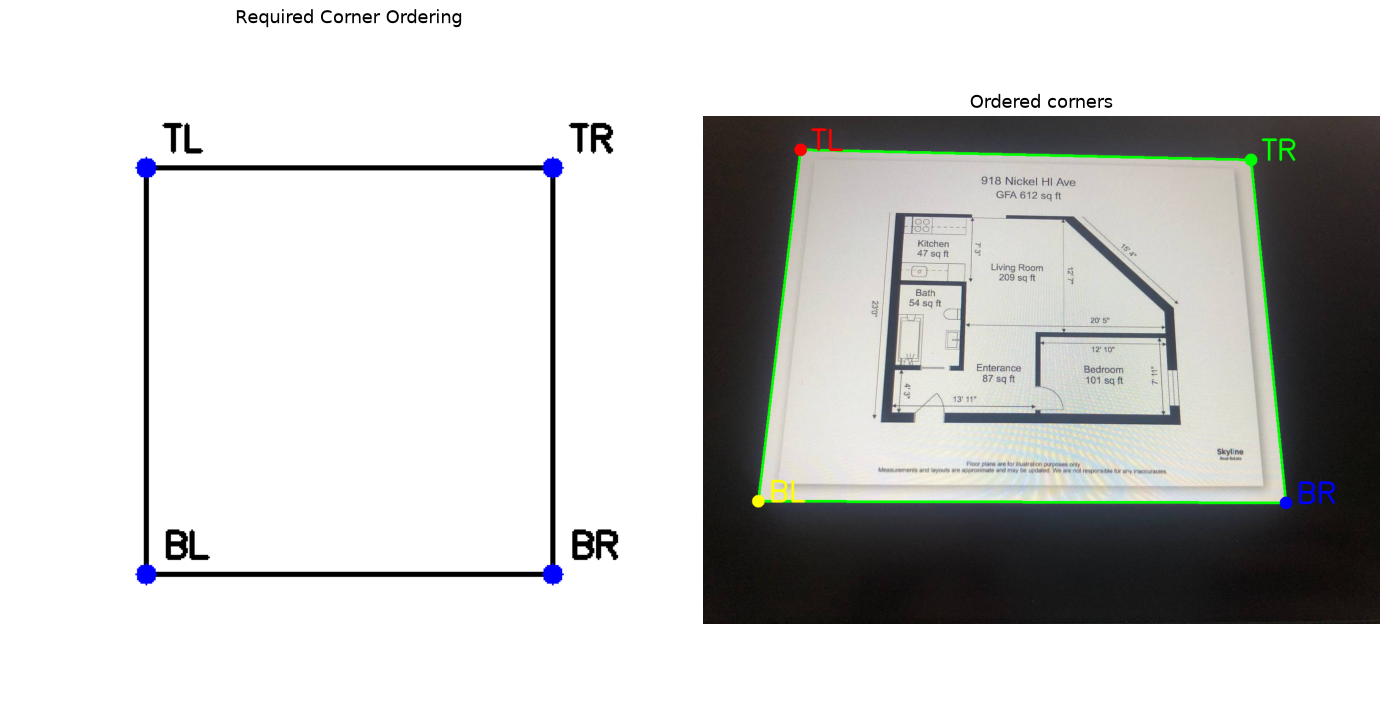

In [135]:
overlay = phone_rgb.copy()

cv2.polylines(
    overlay,
    [ordered_corners.astype(np.int32)],
    True,
    (0,255,0),
    3
)

colors = [
    (255,0,0),
    (0,255,0),
    (0,0,255),
    (255,255,0)
]

labels = [
    "TL",      # Top Left
    "TR",      # Top Right
    "BR",      # Bottom Right
    "BL"       # Bottom Left
]

for point, color, label in zip(
    ordered_corners,
    colors,
    labels
):

    x, y = point.astype(int)

    cv2.circle(
        overlay,
        (x, y),
        12,
        color,
        -1
    )

    cv2.putText(
        overlay,
        label,
        (x+20, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.8,
        color,
        4
    );



show_images([diagram, overlay], ["Required Corner Ordering", "Ordered corners"])

## Homography

At this stage, the document boundary has been detected and its four corner
points have been identified.

The goal is now to transform the photographed floor plan into a top-down view,
removing the perspective distortion introduced by the camera.

This transformation is performed using a **homography**.

A homography is a projective transformation represented by a **3 × 3 matrix**
that maps points lying on one plane into another plane.

Since a floor plan is a flat (planar) object, it satisfies the assumptions
required for homography estimation.

The transformation can be summarized as

**Camera**

↓

**Perspective Image**

↓

**Homography Matrix (H)**

↓

**Rectified Top-Down Image**

The resulting image is geometrically normalized and can be used for
segmentation, vectorization, OCR, or geometric measurements.

In [136]:
# Source points
src_points = ordered_corners.astype(np.float32)

print(src_points)

[[ 185.   63.]
 [1036.   82.]
 [1102.  730.]
 [ 105.  727.]]


Instead of selecting an arbitrary output resolution, the destination image size is estimated from the detected document dimensions. This preserves the aspect ratio of the photographed floor plan.

In [137]:
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

In [138]:
width_top = euclidean_distance(src_points[0], src_points[1])
width_bottom = euclidean_distance(src_points[3], src_points[2])

height_left = euclidean_distance(src_points[0], src_points[3])
height_right = euclidean_distance(src_points[1], src_points[2])

max_width = int(max(width_top, width_bottom))
max_height = int(max(height_left, height_right))

In [139]:
print(f"Estimated width : {max_width}")
print(f"Estimated height: {max_height}")

Estimated width : 997
Estimated height: 668


In [140]:
# Destination coordinates
dst_points = np.array([
    [0,0],
    [max_width-1,0],
    [max_width-1,max_height-1],
    [0,max_height-1]
],dtype=np.float32)

In [141]:
print("Source points")
print(src_points)

print()

print("Destination points")
print(dst_points)

Source points
[[ 185.   63.]
 [1036.   82.]
 [1102.  730.]
 [ 105.  727.]]

Destination points
[[  0.   0.]
 [996.   0.]
 [996. 667.]
 [  0. 667.]]


### Computing the Homography

OpenCV provides two commonly used methods for estimating a projective
transformation.

**cv2.getPerspectiveTransform()**

- Requires exactly four point correspondences.
- Computes the unique perspective transformation directly.
- Fast and deterministic.
- Best suited for document rectification.

**cv2.findHomography()**

- Accepts four or more point correspondences.
- Can estimate the homography using robust methods such as RANSAC.
- Automatically rejects incorrect point matches.
- Commonly used in feature matching (SIFT, ORB, SURF) and image stitching.

Since the document corners have already been detected precisely, this notebook
uses `cv2.getPerspectiveTransform()`

In [142]:
H = cv2.getPerspectiveTransform(
    src_points,
    dst_points
)

In [143]:
print("Homography Matrix\n")

print(H)

Homography Matrix

[[ 1.14961221e+00  1.38507495e-01 -2.21404231e+02]
 [-2.65160110e-02  1.18763818e+00 -6.99157431e+01]
 [-3.51793357e-05  2.60207205e-04  1.00000000e+00]]


The homography matrix completely describes the projective transformation
between the photographed document and the rectified top-down view.

Each point in the original image is transformed according to this matrix.

## Warp Perspective

### Applying the Homography

Once the homography matrix has been estimated, it can be applied to every
pixel in the original image.

OpenCV performs this operation using `cv2.warpPerspective()`.

Unlike simple image transformations such as translation or rotation,
perspective warping computes the new position of every pixel according to the
homography matrix.

As a result, the photographed floor plan is transformed into a geometrically
correct top-down view.

The output image size is specified using the estimated document width and
height computed from the detected corner points.

In [144]:
rectified = cv2.warpPerspective(
    phone_rgb,
    H,
    (max_width,max_height)
)

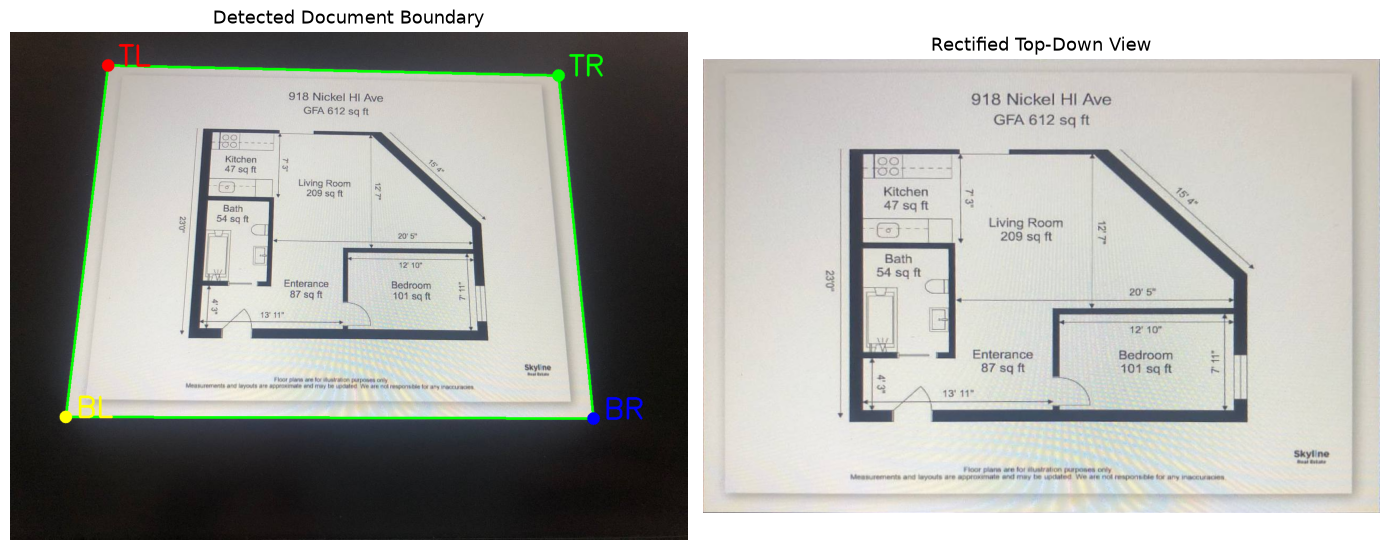

In [145]:
show_images(
    [overlay, rectified], 
    ["Detected Document Boundary", "Rectified Top-Down View"],
    )

In [146]:
print(f"Original image size : {phone_rgb.shape[1]} × {phone_rgb.shape[0]}")
print(f"Rectified image size: {rectified.shape[1]} × {rectified.shape[0]}")

Original image size : 1280 × 960
Rectified image size: 997 × 668


The rectified floor plan is saved to the project's output/ directory. This image serves as the input for the next notebook, where additional preprocessing will be applied.

In [151]:
save_image(rectified, "../output/rectified_floor_plan.png")

## Conclusion

The perspective correction successfully transformed the floor plan from an
oblique camera view into a top-down representation.

Without homography:

- wall lengths are distorted
- right angles are lost
- room areas become inaccurate
- segmentation models must learn viewpoint variations
- vectorization becomes less reliable

After rectification:

- document borders become approximately parallel
- horizontal and vertical walls became better aligned
- room proportions became more consistent
- perspective distortion is removed

These improvements simplify downstream tasks such as segmentation,
wall extraction, OCR, and vectorization.

## Limitations and Future Improvements

The current pipeline assumes that the floor plan occupies most of the image and
that its boundary can be accurately extracted using classical edge detection and
contour analysis.

While this assumption is valid for many scanned documents and controlled
photographs, several situations can reduce the robustness of the pipeline:

- the document is partially outside the image
- motion blur obscures the document edges
- reflections or screen glare hide portions of the boundary
- heavy shadows reduce edge contrast
- the document is folded or curved
- other objects partially occlude the floor plan

In production systems, the contour detection stage can be replaced by learned
document detectors or segmentation models.

For example:

- object detectors can localize the document with a bounding box
- segmentation models can predict an accurate document mask
- foundation models can generalize to a wider range of document appearances

These approaches are typically more robust when the document boundary is
difficult to extract using classical image processing techniques.

Examples include YOLO for object detection, Detectron2 for instance segmentation, or SAM for promptable segmentation when images contain clutter, occlusions, or challenging lighting conditions.

## Next Steps

The floor plan has now been geometrically normalized and is ready for further
image preprocessing.

The next notebook in this project focuses on preparing the rectified floor plan
for segmentation by improving image quality.

The preprocessing pipeline will include:

- contrast enhancement (CLAHE)
- adaptive thresholding
- morphological operations (opening and closing)
- noise removal
- image sharpening

The processed image will then be used for wall extraction, room segmentation,
polygon vectorization, and structured JSON export.